In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kmeans_alternate import KMeansAlternate
from kmeans_custom import KMeansCustom
import time

%matplotlib inline

In [2]:
iris = pd.read_csv('data/iris.csv')
ai   = pd.read_csv('data/ai_index.csv')
eq   = pd.read_csv('data/earthquakes.csv')

def preprocess_iris(df):
    df = df.drop(columns=['species'])
    df = df.dropna()
    return StandardScaler().fit_transform(df)

def preprocess_ai(df):
    df = df.select_dtypes(include=[np.number])
    df = df.dropna()
    return StandardScaler().fit_transform(df)

def preprocess_eq(df):
    df = df[['magnitude','depth','latitude','longitude']]
    df = df.dropna()
    return StandardScaler().fit_transform(df)

iris_data = preprocess_iris(iris)
ai_data   = preprocess_ai(ai)
eq_data   = preprocess_eq(eq)

print("Iris:", iris_data.shape)
print("AI Index:", ai_data.shape)
print("Earthquakes:", eq_data.shape)

Iris: (150, 4)
AI Index: (62, 8)
Earthquakes: (1137, 4)


In [3]:
K_VALUES = [2, 5, 10, 20]

# Quick test on iris with k=3
alt    = KMeansAlternate(k=3)
custom = KMeansCustom(k=3)
sk     = KMeans(n_clusters=3, random_state=42, n_init=1)

alt.fit(iris_data)
custom.fit(iris_data)
sk.fit(iris_data)

print("=== Alternate Variant ===")
print("Iterations:", alt.n_iterations)
print("Final SSE: ", round(alt.sse_history[-1], 4))

print("\n=== Custom (ESPI + Border Point) ===")
print("Iterations:", custom.n_iterations)
print("Final SSE: ", round(custom.sse_history[-1], 4))

print("\n=== Sklearn ===")
print("Iterations:", sk.n_iter_)
print("Final SSE: ", round(sk.inertia_, 4))

=== Alternate Variant ===
Iterations: 3
Final SSE:  440.2481

=== Custom (ESPI + Border Point) ===
Iterations: 100
Final SSE:  140.9658

=== Sklearn ===
Iterations: 4
Final SSE:  192.0372


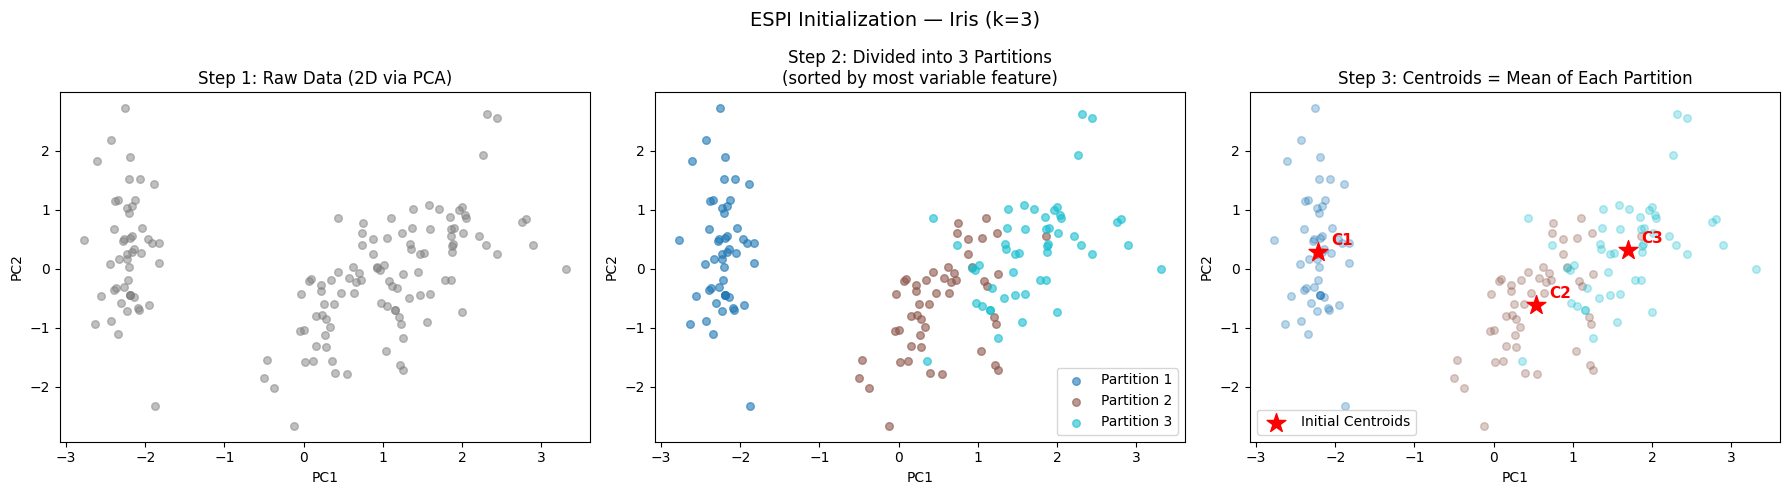

Dominant feature index: 3
Centroid positions (2D):
[[-2.22019328  0.29222482]
 [ 0.52897252 -0.6139892 ]
 [ 1.69122076  0.32176438]]


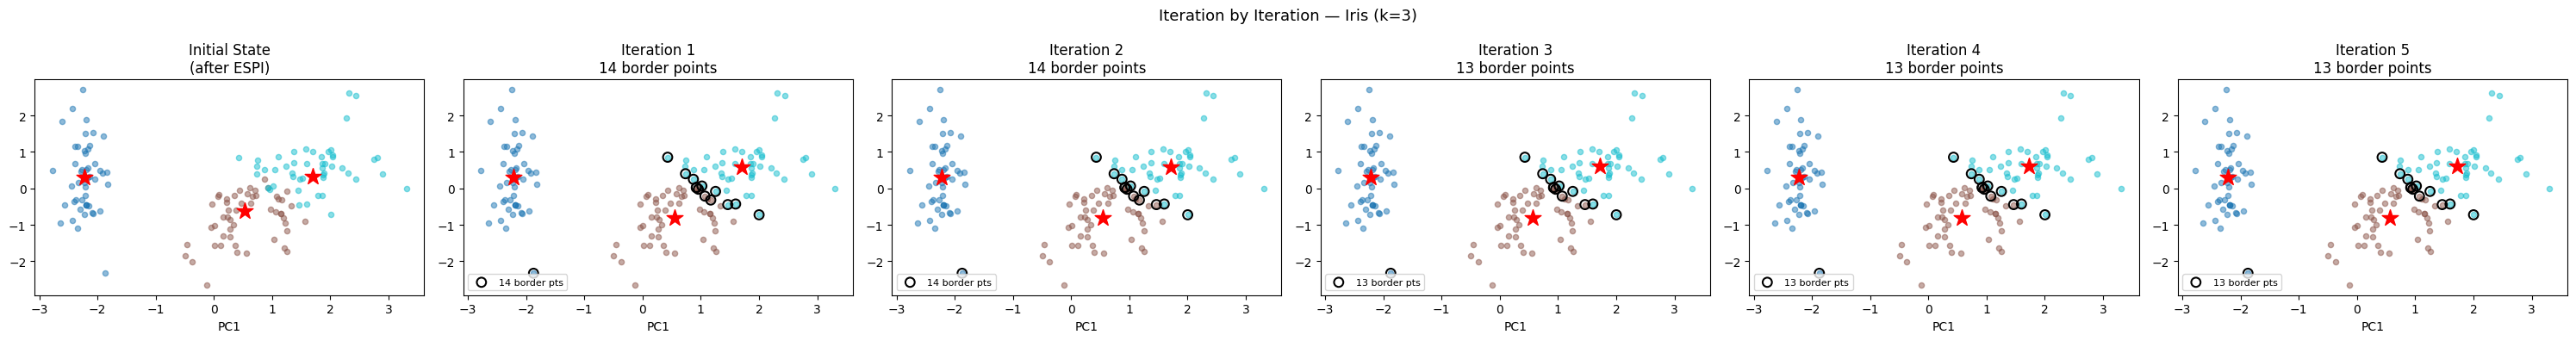